In [31]:
from datasets import load_dataset

dataset = load_dataset("imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [32]:
import pandas as pd

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(train_df.shape)
print(train_df.head())

(25000, 2)
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


In [33]:
train_df['label'].unique()


array([0, 1])

Text(0, 0.5, 'Liczba opinii')

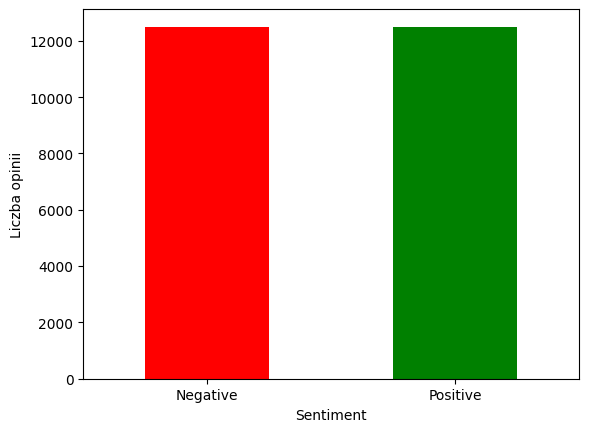

In [34]:
import matplotlib.pyplot as plt
train_df['label'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)
plt.xlabel("Sentiment")
plt.ylabel("Liczba opinii")


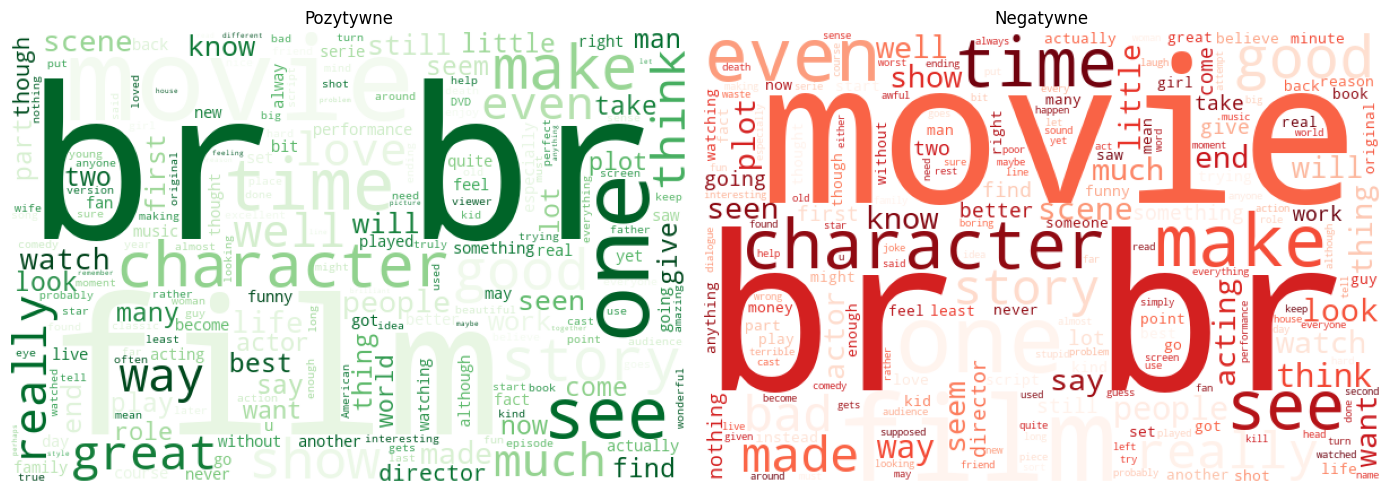

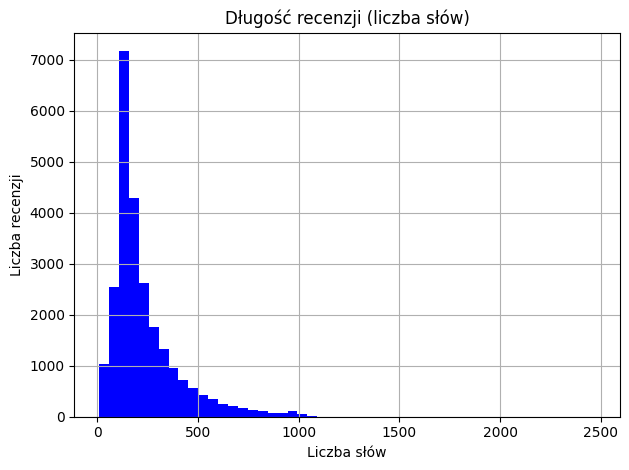

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: text_length, dtype: float64


In [35]:
train_df['text_length'] = train_df['text'].str.split().str.len()

from wordcloud import WordCloud

# teksty
positive_text = ' '.join(train_df[train_df['label'] == 1]['text'])
negative_text = ' '.join(train_df[train_df['label'] == 0]['text'])

# wykresy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔹 Pozytywne
wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(positive_text)
axes[0].imshow(wc_pos)
axes[0].set_title('Pozytywne')
axes[0].axis('off')

# 🔹 Negatywne
wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(negative_text)
axes[1].imshow(wc_neg)
axes[1].set_title('Negatywne')
axes[1].axis('off')

plt.tight_layout()
plt.show()
train_df['text_length'].hist(bins=50, color='blue')
plt.title('Długość recenzji (liczba słów)')
plt.xlabel('Liczba słów')
plt.ylabel('Liczba recenzji')
plt.tight_layout()
plt.show()

print(train_df['text_length'].describe())

In [36]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

print(train_df['clean_text'].iloc[0])

rented curious yellow video store controversy surrounded released heard seized u s customs tried enter country fan films considered controversial really plot centered young swedish drama student named lena wants learn life particular wants focus attentions making sort documentary average swede thought certain political issues vietnam war race issues united states asking politicians ordinary denizens stockholm opinions politics sex drama teacher classmates married men kills curious yellow years ago considered pornographic really sex nudity scenes far s shot like cheaply porno countrymen mind shocking reality sex nudity major staple swedish cinema ingmar bergman arguably answer good old boy john ford sex scenes films commend filmmakers fact sex shown film shown artistic purposes just shock people make money shown pornographic theaters america curious yellow good film wanting study meat potatoes pun intended swedish cinema really film doesn t plot


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score


tfidf = TfidfVectorizer(max_features=10000)
X_train = tfidf.fit_transform(train_df['clean_text'])
X_test = tfidf.transform(test_df['clean_text'])

y_train = train_df['label']
y_test = test_df['label']

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

Accuracy: 0.8810
F1 Score: 0.8811


In [38]:
from sklearn.metrics import confusion_matrix
#sprawdzamy tp tn fp fn
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10996  1504]
 [ 1472 11028]]


In [39]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", 
                       model="distilbert-base-uncased-finetuned-sst-2-english",
                       truncation=True,
                       max_length=512)

# Testujemy na małej próbce najpierw
sample_texts = test_df['text'].iloc[:5].tolist()
results = classifier(sample_texts)

for text, result in zip(sample_texts, results):
    print(f"Sentiment: {result['label']} ({result['score']:.4f})")
    print(f"Text: {text}")
    print()

Loading weights: 100%|██████████████████████| 104/104 [00:00<00:00, 5903.31it/s]


Sentiment: NEGATIVE (0.9996)
Text: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi TV. It's not. It's clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It's really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW

In [40]:

results_all = classifier(test_df['text'].tolist(), batch_size=32, truncation=True, max_length=512)


y_pred_bert = [1 if r['label'] == 'POSITIVE' else 0 for r in results_all]

print(f"dokladnosc : {accuracy_score(y_test, y_pred_bert):.4f}")
print(f"f1 : {f1_score(y_test, y_pred_bert):.4f}")

dokladnosc : 0.8907
f1 : 0.8875


In [41]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'DistilBERT'],
    'Accuracy': [0.8810, 0.8907],
    'F1 Score': [0.8811, 0.8875],
    'Czas trenowania': ['ok 30 sek', 'ok 30 min']
})

print(results_df.to_string(index=False))

              Model  Accuracy  F1 Score Czas trenowania
Logistic Regression    0.8810    0.8811       ok 30 sek
         DistilBERT    0.8907    0.8875       ok 30 min


In [42]:
test_df['pred_lr'] = y_pred
test_df['pred_bert'] = y_pred_bert
both_wrong = test_df[
    (test_df['pred_lr'] != test_df['label']) &
    (test_df['pred_bert'] != test_df['label'])
]

print("Liczba bledow obu modeli:", len(both_wrong))


for i in range(3):
    row = both_wrong.iloc[i]
    
    print("Prawdziwy:", "POSITIVE" if row['label'] == 1 else "NEGATIVE")
    print("Tekst:", row['text'])
    

Liczba bledow obu modeli: 1041
Prawdziwy: NEGATIVE
Tekst: First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!
Prawdziwy: NEGATIVE
Tekst: Low budget horror movie. If you don't raise your expectations too high, you'll probably enjoy this little flick. Beginning and end are pretty good, middle drags at times and seems to go nowhere for long periods as we watch the goings on of th